In [1]:
!uv pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.8/107.7 GB disk)


In [2]:
# Run inference on an image with YOLO26n
!yolo predict model=yolo26n.pt source='https://ultralytics.com/images/zidane.jpg'

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs

image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 103.7ms
Speed: 11.9ms preprocess, 103.7ms inference, 5.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [9]:
# Print out result for zidane.jpg
from ultralytics import YOLO
model = YOLO("yolo26n.pt")
results = model("https://ultralytics.com/images/zidane.jpg")
r = results[0]
print("Classes:", [r.names[int(c)] for c in r.boxes.cls])
print("Boxes:", r.boxes.xyxy)


Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 83.8ms
Speed: 2.2ms preprocess, 83.8ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)
Classes: ['person', 'person', 'tie']
Boxes: tensor([[ 744.6178,   40.5441, 1150.2798,  711.7892],
        [ 120.3859,  201.6768,  981.4985,  713.7363],
        [ 433.1679,  430.6905,  525.5728,  714.9482]])


In [17]:
results = model("Yue_Image_Upload.jpg")
r = results[0]
print("Classes:", [r.names[int(c)] for c in r.boxes.cls])
print("Boxes:", r.boxes.xyxy)


image 1/1 /content/Yue_Image_Upload.jpg: 640x608 3 bottles, 135.7ms
Speed: 3.7ms preprocess, 135.7ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 608)
Classes: ['bottle', 'bottle', 'bottle']
Boxes: tensor([[ 31.3094,   6.3221, 138.8393, 362.0440],
        [131.9352,   5.2669, 238.8378, 364.5299],
        [233.0781,   6.1498, 334.6879, 363.6406]])


(np.float64(-0.5), np.float64(356.5), np.float64(386.5), np.float64(-0.5))

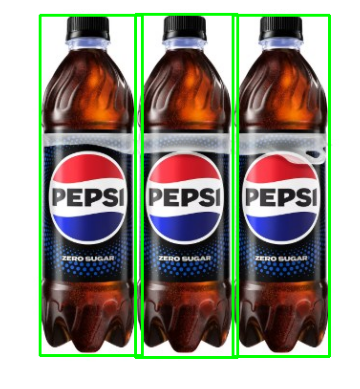

In [18]:
import numpy as np
import cv2
# get image as numpy array
img = r.orig_img.copy()

for box, conf, cls in zip(r.boxes.xyxy, r.boxes.conf, r.boxes.cls):
    x1, y1, x2, y2 = map(int, box)

    # draw rectangle
    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

    # label
    label = f"{r.names[int(cls)]} {conf:.2f}"
    cv2.putText(img, label, (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

# show
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")